# 🏦 Stage 9: Ensemble Methods & XGBoost
## Project: Credit Risk Scoring Engine

## 📦 1. Imports & Configuration

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings, time
warnings.filterwarnings('ignore')

# Core ML
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                             classification_report, confusion_matrix,
                             average_precision_score)
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline

# Boosting
import xgboost  as xgb
import lightgbm as lgb

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# SHAP
import shap

# ── Plot theme ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0a0a14',
    'axes.facecolor':   '#12121f',
    'axes.edgecolor':   '#3a3a5c',
    'text.color':       '#dcdcff',
    'axes.labelcolor':  '#dcdcff',
    'xtick.color':      '#9090b8',
    'ytick.color':      '#9090b8',
    'grid.color':       '#222240',
    'grid.alpha':       0.6,
    'legend.facecolor': '#1a1a30',
    'legend.edgecolor': '#404060',
})

C_XGB     = '#00d4ff'   # cyan
C_LGBM    = '#00ff9f'   # green
C_STACK   = '#ffd700'   # gold
C_ACTUAL  = '#ff6b6b'   # red
C_NEUTRAL = '#a0a0d0'   # soft purple

print("✅ All imports successful!")
for lib, obj in [('XGBoost', xgb), ('LightGBM', lgb), ('SHAP', shap),
                 ('imbalanced-learn', __import__('imblearn'))]:
    print(f"   {lib:18s}: {obj.__version__}")


✅ All imports successful!
   XGBoost           : 3.3.0
   LightGBM          : 4.6.0
   SHAP              : 0.52.0
   imbalanced-learn  : 0.14.2


## 📊 2. Synthetic Dataset Generation

We recreate the **GiveMeSomeCredit** schema: 150,000 borrowers, 10 financial features,  
~7 % default rate (severe class imbalance).
 

In [6]:
np.random.seed(42)
N = 150_000

# ── Base population ──────────────────────────────────────────────────────────
age           = np.random.normal(52, 14, N).clip(18, 109).astype(int)
income        = np.random.lognormal(np.log(5500), 0.65, N).clip(0, 99_999)
dependents    = np.random.choice([0,1,2,3,4,5], N, p=[0.33,0.28,0.22,0.10,0.05,0.02])

# Credit utilisation (right-skewed, some > 1 = maxed out)
revolving_util = np.random.beta(1.5, 4, N) * 1.3
revolving_util = revolving_util.clip(0, 1.5)

debt_ratio     = np.random.lognormal(np.log(0.35), 0.9, N).clip(0, 50)
open_credit    = np.random.poisson(8, N).clip(0, 58)
real_estate    = np.random.poisson(1.0, N).clip(0, 54)

late_30_59    = np.random.choice([0,1,2,3,4,5,6], N, p=[0.83,0.08,0.05,0.02,0.01,0.005,0.005])
late_60_89    = np.random.choice([0,1,2,3,4,5],   N, p=[0.91,0.05,0.02,0.01,0.005,0.005])
late_90       = np.random.choice([0,1,2,3,4,5],   N, p=[0.92,0.04,0.02,0.01,0.005,0.005])

# ── Compute default probability (logistic) ───────────────────────────────────
logit = (
    - 2.8
    + 1.8  * revolving_util
    - 0.015* age
    - 0.00002 * income
    + 0.5  * debt_ratio.clip(0, 5)
    + 0.6  * late_30_59.clip(0, 5)
    + 0.9  * late_60_89.clip(0, 5)
    + 1.2  * late_90.clip(0, 5)
    + 0.15 * dependents
    + np.random.normal(0, 0.6, N)
)
prob_default   = 1 / (1 + np.exp(-logit))
default_flag   = (np.random.uniform(0, 1, N) < prob_default).astype(int)

# ── Inject ~5 % missing values in income & dependents (like real dataset) ────
income_m    = income.astype(float)
dependents_m= dependents.astype(float)
income_m[np.random.choice(N, int(N * 0.05), replace=False)]     = np.nan
dependents_m[np.random.choice(N, int(N * 0.025), replace=False)] = np.nan

# ── Assemble DataFrame ───────────────────────────────────────────────────────
df = pd.DataFrame({
    'RevolvingUtilizationOfUnsecuredLines':   revolving_util,
    'age':                                     age,
    'NumberOfTime30-59DaysPastDueNotWorse':    late_30_59,
    'DebtRatio':                               debt_ratio,
    'MonthlyIncome':                           income_m,
    'NumberOfOpenCreditLinesAndLoans':         open_credit,
    'NumberOfTimes90DaysLate':                 late_90,
    'NumberRealEstateLoansOrLines':            real_estate,
    'NumberOfTime60-89DaysPastDueNotWorse':    late_60_89,
    'NumberOfDependents':                      dependents_m,
    'SeriousDlqin2yrs':                        default_flag,
})

df.to_csv('credit_risk_synthetic.csv', index=False)

default_rate = df['SeriousDlqin2yrs'].mean()
print(f"✅ Dataset generated — {len(df):,} borrowers")
print(f"   Default rate : {default_rate:.2%}  (imbalance ratio 1:{int(1/default_rate):.0f})")
print(f"   Missing — MonthlyIncome  : {df['MonthlyIncome'].isna().sum():,}")
print(f"   Missing — NumberOfDependents : {df['NumberOfDependents'].isna().sum():,}")
print()
print(df.describe().round(2).to_string())


✅ Dataset generated — 150,000 borrowers
   Default rate : 16.13%  (imbalance ratio 1:6)
   Missing — MonthlyIncome  : 7,500
   Missing — NumberOfDependents : 3,750

       RevolvingUtilizationOfUnsecuredLines        age  NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  NumberRealEstateLoansOrLines  NumberOfTime60-89DaysPastDueNotWorse  NumberOfDependents  SeriousDlqin2yrs
count                             150000.00  150000.00                             150000.00  150000.00      142500.00                        150000.00                150000.00                      150000.0                             150000.00           146250.00         150000.00
mean                                   0.35      51.56                                  0.34       0.53        6784.60                             7.99                     0.16                           1.0                                  0.16                1.32     

## 🔍 3. Exploratory Data Analysis

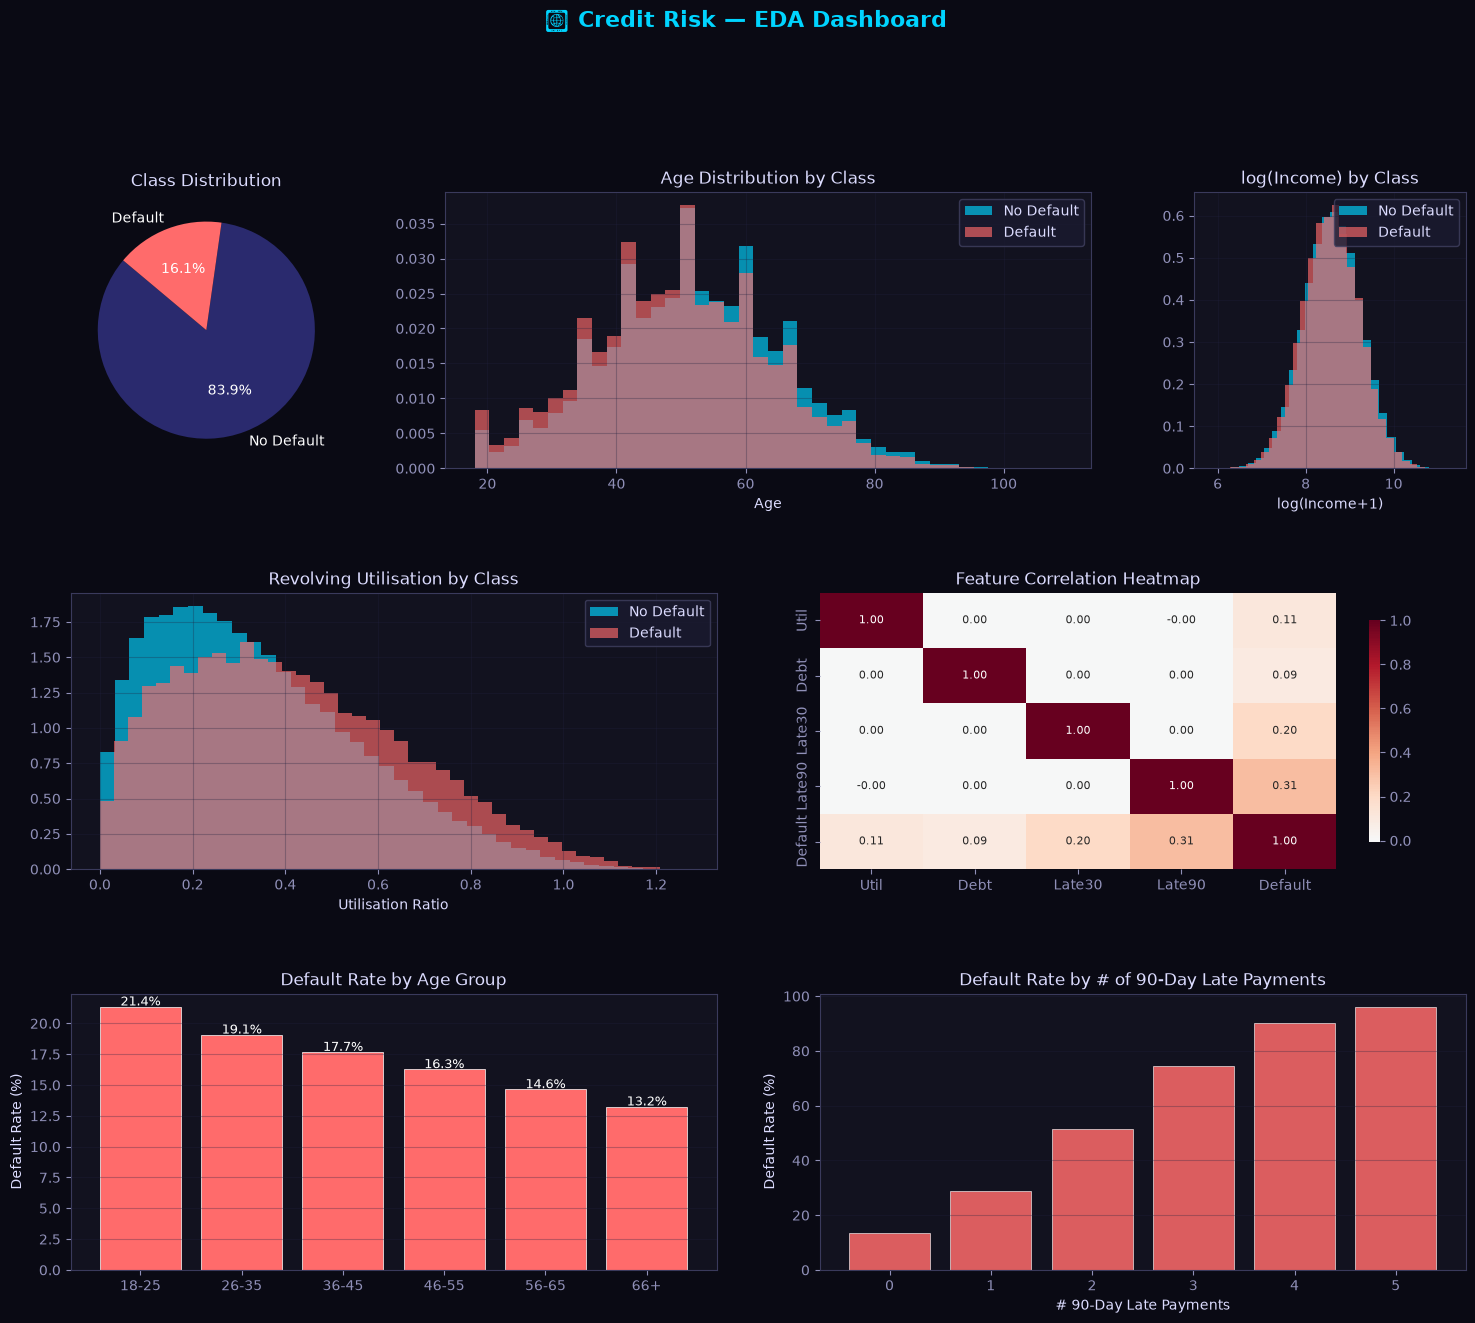

✅ EDA dashboard saved → eda_credit.png


In [ ]:

FEAT_COLS = [c for c in df.columns if c != 'SeriousDlqin2yrs']
TARGET    = 'SeriousDlqin2yrs'

fig = plt.figure(figsize=(18, 14))
fig.suptitle('📊 Credit Risk — EDA Dashboard', fontsize=16,
             color=C_XGB, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.38)

ax0 = fig.add_subplot(gs[0, 0])
counts = df[TARGET].value_counts()
ax0.pie(counts, labels=['No Default','Default'],
        colors=['#2a2a6e', C_ACTUAL], autopct='%1.1f%%',
        startangle=140, textprops={'color':'white', 'fontsize':10})
ax0.set_title('Class Distribution', color='#dcdcff')

ax1 = fig.add_subplot(gs[0, 1:3])
for val, color, lbl in [(0, C_XGB, 'No Default'), (1, C_ACTUAL, 'Default')]:
    ax1.hist(df[df[TARGET]==val]['age'], bins=40, alpha=0.65,
             color=color, label=lbl, density=True)
ax1.set_title('Age Distribution by Class', color='#dcdcff')
ax1.set_xlabel('Age'); ax1.legend(); ax1.grid(True, alpha=0.3)

# ── Income by class (log) ────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 3])
df_nona = df.dropna(subset=['MonthlyIncome'])
for val, color, lbl in [(0, C_XGB, 'No Default'), (1, C_ACTUAL, 'Default')]:
    ax2.hist(np.log1p(df_nona[df_nona[TARGET]==val]['MonthlyIncome']),
             bins=30, alpha=0.65, color=color, label=lbl, density=True)
ax2.set_title('log(Income) by Class', color='#dcdcff')
ax2.set_xlabel('log(Income+1)'); ax2.legend(); ax2.grid(True, alpha=0.3)

# ── Revolving utilisation by class ───────────────────────────────────────────


ax3 = fig.add_subplot(gs[1, 0:2])
for val, color, lbl in [(0, C_XGB, 'No Default'), (1, C_ACTUAL, 'Default')]:
    ax3.hist(df[df[TARGET]==val]['RevolvingUtilizationOfUnsecuredLines'].clip(0,1.5),
             bins=40, alpha=0.65, color=color, label=lbl, density=True)
ax3.set_title('Revolving Utilisation by Class', color='#dcdcff')
ax3.set_xlabel('Utilisation Ratio'); ax3.legend(); ax3.grid(True, alpha=0.3)

# ── Late payments correlation heatmap ─
ax4 = fig.add_subplot(gs[1, 2:4])
corr_cols = ['RevolvingUtilizationOfUnsecuredLines','DebtRatio',
             'NumberOfTime30-59DaysPastDueNotWorse',
             'NumberOfTimes90DaysLate','SeriousDlqin2yrs']
corr = df[corr_cols].corr()
sns.heatmap(corr, ax=ax4, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            annot_kws={'size':8}, cbar_kws={'shrink':0.8},
            xticklabels=['Util','Debt','Late30','Late90','Default'],
            yticklabels=['Util','Debt','Late30','Late90','Default'])
ax4.set_title('Feature Correlation Heatmap', color='#dcdcff')

# ── Default rate by age bucket ────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0:2])
df['age_bin'] = pd.cut(df['age'], bins=[17,25,35,45,55,65,109],
                       labels=['18-25','26-35','36-45','46-55','56-65','66+'])
dr_age = df.groupby('age_bin', observed=True)[TARGET].mean()
bars = ax5.bar(dr_age.index, dr_age.values * 100,
               color=[C_ACTUAL if v > 0.1 else C_XGB for v in dr_age.values],
               edgecolor='white', linewidth=0.5)
ax5.set_title('Default Rate by Age Group', color='#dcdcff')
ax5.set_ylabel('Default Rate (%)'); ax5.grid(True, alpha=0.3, axis='y')
for b in bars:
    ax5.text(b.get_x()+b.get_width()/2, b.get_height()+0.1,
             f'{b.get_height():.1f}%', ha='center', fontsize=9, color='white')

# ── Default rate by late payments ────────────────────────────────────────────
ax6 = fig.add_subplot(gs[2, 2:4])
dr_late = df.groupby('NumberOfTimes90DaysLate')[TARGET].mean().reset_index()
dr_late = dr_late[dr_late['NumberOfTimes90DaysLate'] <= 5]
ax6.bar(dr_late['NumberOfTimes90DaysLate'], dr_late[TARGET]*100,
        color=C_ACTUAL, edgecolor='white', linewidth=0.5, alpha=0.85)
ax6.set_title('Default Rate by # of 90-Day Late Payments', color='#dcdcff')
ax6.set_xlabel('# 90-Day Late Payments'); ax6.set_ylabel('Default Rate (%)')
ax6.grid(True, alpha=0.3, axis='y')

plt.savefig('eda_credit.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ EDA dashboard saved → eda_credit.png")


## 🔧 4. Preprocessing — Missing Values, Feature Engineering & Splitting


In [ ]:


df_clean = df.drop(columns=['age_bin']).copy() 

# ── Median imputation ─────────────────────────────────────────────────────────
df_clean['MonthlyIncome']     = df_clean['MonthlyIncome'].fillna(
    df_clean['MonthlyIncome'].median())
df_clean['NumberOfDependents'] = df_clean['NumberOfDependents'].fillna(
    df_clean['NumberOfDependents'].median())

# ── Feature engineering ───────────────────────────────────────────────────────
df_clean['TotalLatePayments'] = (
    df_clean['NumberOfTime30-59DaysPastDueNotWorse']
    + df_clean['NumberOfTime60-89DaysPastDueNotWorse']
    + df_clean['NumberOfTimes90DaysLate']
)
df_clean['DebtToIncome'] = df_clean['DebtRatio'] * df_clean['MonthlyIncome'] / (df_clean['MonthlyIncome'] + 1)
df_clean['UtilXLate']    = df_clean['RevolvingUtilizationOfUnsecuredLines'] * df_clean['TotalLatePayments']
df_clean['IncomePerDep'] = df_clean['MonthlyIncome'] / (df_clean['NumberOfDependents'] + 1)

FEATURE_COLS = [c for c in df_clean.columns if c != TARGET]
X = df_clean[FEATURE_COLS]
y = df_clean[TARGET]

# ── Train / Validation / Test split (60/20/20) ────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20,
                                                    random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25,
                                                    random_state=42, stratify=y_temp)

print(f"✅ Preprocessing complete")
print(f"   Features   : {len(FEATURE_COLS)}  ({', '.join(FEATURE_COLS[:5])} …)")
print(f"   Train set  : {X_train.shape[0]:,} samples  (default {y_train.mean():.2%})")
print(f"   Val set    : {X_val.shape[0]:,} samples  (default {y_val.mean():.2%})")
print(f"   Test set   : {X_test.shape[0]:,} samples  (default {y_test.mean():.2%})")

✅ Preprocessing complete
   Features   : 14  (RevolvingUtilizationOfUnsecuredLines, age, NumberOfTime30-59DaysPastDueNotWorse, DebtRatio, MonthlyIncome …)
   Train set  : 90,000 samples  (default 16.13%)
   Val set    : 30,000 samples  (default 16.13%)
   Test set   : 30,000 samples  (default 16.13%)


## ⚖️ 5. Handling Class Imbalance with SMOTE


Before SMOTE  — Train default rate: 16.13%  (14,517 defaults)
After SMOTE   — Train default rate: 23.08%  (22,644 defaults)
   New training size: 98,127 samples


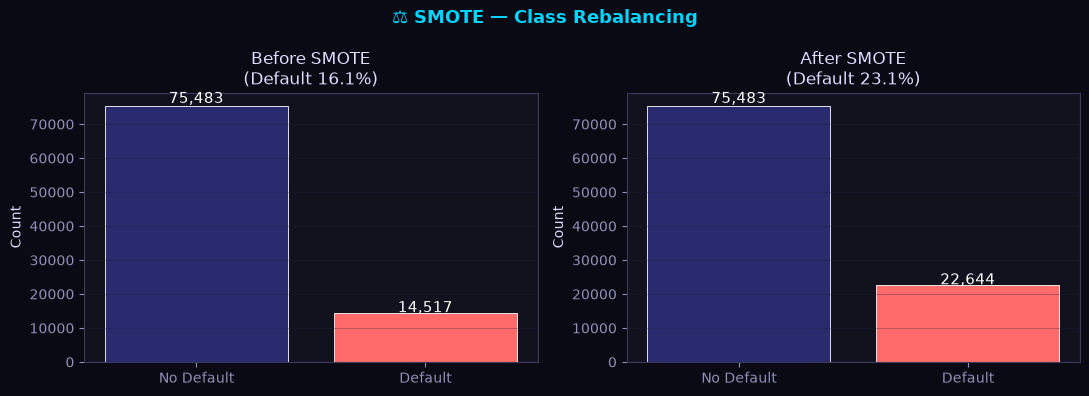

✅ SMOTE balance plot saved → smote_balance.png


In [ ]:
print(f"Before SMOTE  — Train default rate: {y_train.mean():.2%}  ({y_train.sum():,} defaults)") 

smote = SMOTE(sampling_strategy=0.3, random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"After SMOTE   — Train default rate: {y_train_sm.mean():.2%}  ({y_train_sm.sum():,} defaults)")
print(f"   New training size: {len(X_train_sm):,} samples")

# Visualise class balance
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('⚖️ SMOTE — Class Rebalancing', fontsize=13, color=C_XGB, fontweight='bold')

for ax, (y_data, title) in zip(
    axes,
    [
        (
            y_train,
            f'Before SMOTE\n(Default {y_train.mean():.1%})'
        ),
        (
            y_train_sm,
            f'After SMOTE\n(Default {y_train_sm.mean():.1%})'
        ),
    ]
):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(['No Default','Default'], counts.values,
                  color=['#2a2a6e', C_ACTUAL], edgecolor='white', linewidth=0.6)
    ax.set_title(title, color='#dcdcff')
    ax.set_ylabel('Count')
    ax.grid(True, axis='y', alpha=0.3)
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()*1.01,
                f'{int(b.get_height()):,}', ha='center', fontsize=11, color='white')

plt.tight_layout()
plt.savefig('smote_balance.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ SMOTE balance plot saved → smote_balance.png")


## 🚀 6. XGBoost — Extreme Gradient Boosting


In [ ]:
scale_pw = int((y_train_sm == 0).sum() / (y_train_sm == 1).sum())


xgb_params = dict(
    n_estimators       = 500,
    max_depth          = 5,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    min_child_weight   = 5,
    gamma              = 0.1,
    reg_alpha          = 0.1,
    reg_lambda         = 1.0,
    scale_pos_weight   = 1,          
    eval_metric        = 'auc',
    early_stopping_rounds = 40,
    random_state       = 42,
    n_jobs             = -1,
)

print("⏳ Training XGBoost …")
t0 = time.time()

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set   = [(X_val, y_val)],
    verbose    = False,
)

print(f"   Done in {time.time()-t0:.1f}s — best iteration: {xgb_model.best_iteration}")

xgb_val_prob  = xgb_model.predict_proba(X_val)[:, 1]
xgb_test_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc_val   = roc_auc_score(y_val,  xgb_val_prob)
xgb_auc_test  = roc_auc_score(y_test, xgb_test_prob)

print(f"✅ XGBoost  — Val AUC: {xgb_auc_val:.4f}  |  Test AUC: {xgb_auc_test:.4f}")


⏳ Training XGBoost …
   Done in 3.4s — best iteration: 105
✅ XGBoost  — Val AUC: 0.7858  |  Test AUC: 0.7819


## ⚡ 7. LightGBM — Light Gradient Boosting Machine


In [ ]:
lgb_params = dict(
    n_estimators        = 500,
    max_depth           = -1,
    num_leaves          = 63,
    learning_rate       = 0.05,
    subsample           = 0.8,
    colsample_bytree    = 0.8,
    min_child_samples   = 20,
    reg_alpha           = 0.1,
    reg_lambda          = 1.0,
    n_jobs              = -1,
    random_state        = 42,
)

print("⏳ Training LightGBM …")
t0 = time.time()

lgb_model = lgb.LGBMClassifier(**lgb_params)
lgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set            = [(X_val, y_val)],
    callbacks           = [lgb.early_stopping(40, verbose=False),
                           lgb.log_evaluation(period=-1)],
)

print(f"   Done in {time.time()-t0:.1f}s — best iteration: {lgb_model.best_iteration_}")

lgb_val_prob  = lgb_model.predict_proba(X_val)[:, 1]
lgb_test_prob = lgb_model.predict_proba(X_test)[:, 1]
lgb_auc_val   = roc_auc_score(y_val,  lgb_val_prob)
lgb_auc_test  = roc_auc_score(y_test, lgb_test_prob)

print(f"✅ LightGBM — Val AUC: {lgb_auc_val:.4f}  |  Test AUC: {lgb_auc_test:.4f}")

⏳ Training LightGBM …
[LightGBM] [Info] Number of positive: 22644, number of negative: 75483
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005915 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1697
[LightGBM] [Info] Number of data points in the train set: 98127, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230762 -> initscore=-1.204013
[LightGBM] [Info] Start training from score -1.204013
   Done in 3.1s — best iteration: 105
✅ LightGBM — Val AUC: 0.7859  |  Test AUC: 0.7808


## 🏗️ 8. Stacking Ensemble

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Step 1: Base Models உருவாக்குதல்
estimators = [
    ('xgb',  xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.08,
                                 subsample=0.8, colsample_bytree=0.8,
                                 random_state=42, n_jobs=-1)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=300, num_leaves=31, learning_rate=0.08,
                                  subsample=0.8, colsample_bytree=0.8,
                                  random_state=42, n_jobs=-1)),
    ('gbm',  GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                         learning_rate=0.1, subsample=0.8,
                                         random_state=42)),
]

meta_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)

stack_model = StackingClassifier(
    estimators          = estimators,
    final_estimator     = meta_lr,
    cv                  = 5,
    stack_method        = 'predict_proba',
    passthrough         = False,
    n_jobs              = -1,
)

print("⏳ Training Stacking Ensemble (5-fold CV — takes ~60s) …")
t0 = time.time()
stack_model.fit(X_train_sm, y_train_sm)
print(f"   Done in {time.time()-t0:.1f}s")

stack_val_prob  = stack_model.predict_proba(X_val)[:, 1]
stack_test_prob = stack_model.predict_proba(X_test)[:, 1]
stack_auc_val   = roc_auc_score(y_val,  stack_val_prob)
stack_auc_test  = roc_auc_score(y_test, stack_test_prob)

print(f"✅ Stacking — Val AUC: {stack_auc_val:.4f}  |  Test AUC: {stack_auc_test:.4f}")

⏳ Training Stacking Ensemble (5-fold CV — takes ~60s) …
   Done in 246.3s
✅ Stacking — Val AUC: 0.7831  |  Test AUC: 0.7784


## 📈 9. ROC & Precision-Recall Curves

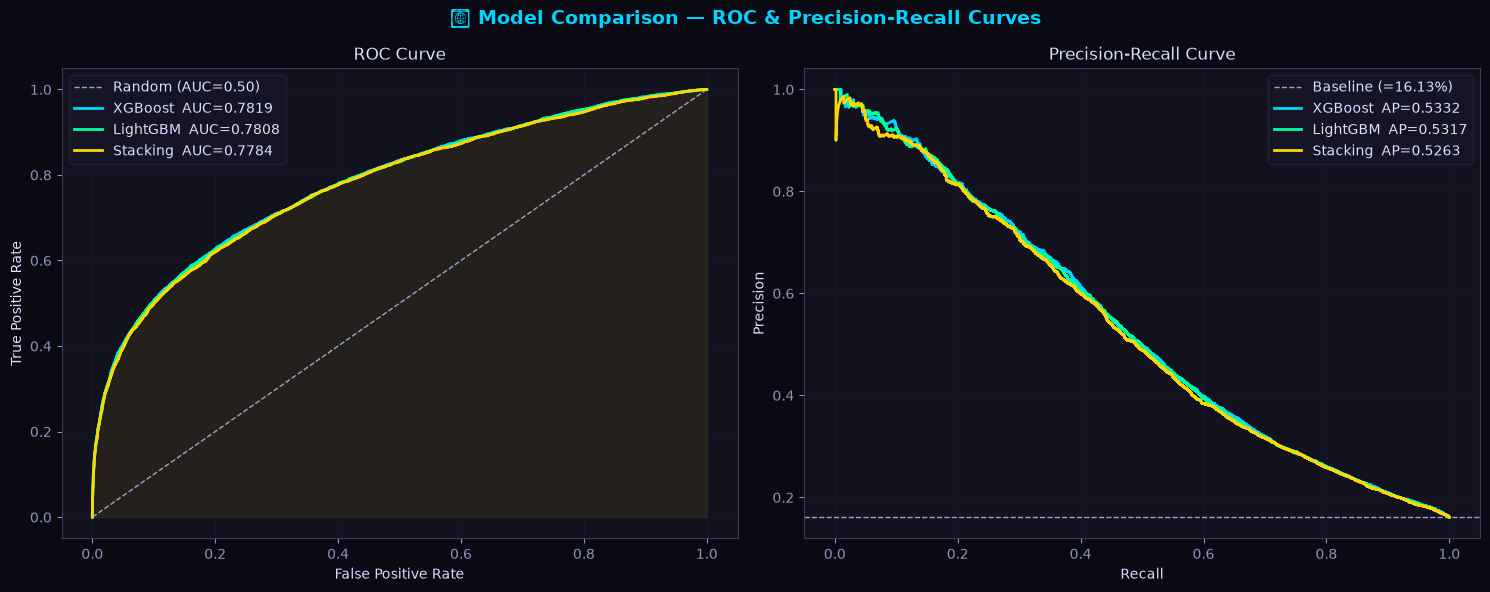

✅ ROC & PR curves saved → roc_pr_curves.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('📈 Model Comparison — ROC & Precision-Recall Curves',
             fontsize=14, color=C_XGB, fontweight='bold')

models_info = [
    ('XGBoost',  xgb_test_prob,   C_XGB),
    ('LightGBM', lgb_test_prob,   C_LGBM),
    ('Stacking', stack_test_prob, C_STACK),
]

# ── ROC ───────────────────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot([0,1],[0,1], '--', color=C_NEUTRAL, linewidth=1, label='Random (AUC=0.50)')
for name, prob, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax1.plot(fpr, tpr, color=color, linewidth=2, label=f'{name}  AUC={auc:.4f}')
ax1.fill_between(*roc_curve(y_test, stack_test_prob)[:2],
                 alpha=0.08, color=C_STACK)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', color='#dcdcff')
ax1.legend(framealpha=0.3); ax1.grid(True, alpha=0.3)

# ── Precision-Recall ───────────────────────────────────────────────────────────
ax2 = axes[1]
baseline = y_test.mean()
ax2.axhline(baseline, linestyle='--', color=C_NEUTRAL, linewidth=1,
            label=f'Baseline (={baseline:.2%})')
for name, prob, color in models_info:
    prec, rec, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    ax2.plot(rec, prec, color=color, linewidth=2, label=f'{name}  AP={ap:.4f}')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', color='#dcdcff')
ax2.legend(framealpha=0.3); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ ROC & PR curves saved → roc_pr_curves.png")


## 💼 10. Business Metrics — KS Statistic & Gini Coefficient



📊 Business Metrics Summary
             AUC    Gini      KS      AP
Model                                   
XGBoost   0.7819  0.5637  0.4287  0.5332
LightGBM  0.7808  0.5617  0.4252  0.5317
Stacking  0.7784  0.5568  0.4217  0.5263

🥇 Best Model by KS: XGBoost  (KS = 0.4287)


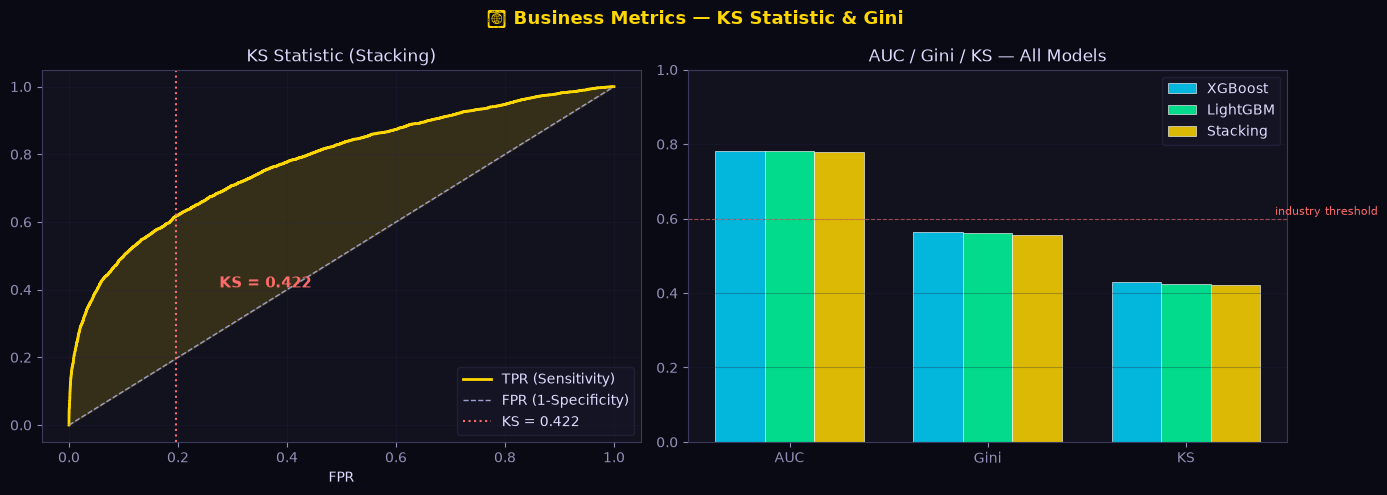

✅ Business metrics plot saved → business_metrics.png


In [ ]:

def business_metrics(y_true, y_prob, model_name, color):
    auc  = roc_auc_score(y_true, y_prob)
    gini = 2 * auc - 1
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    ks   = np.max(tpr - fpr)
    ks_thresh = thresholds[np.argmax(tpr - fpr)]
    ap   = average_precision_score(y_true, y_prob)
    return {
        'Model': model_name, 'AUC': auc, 'Gini': gini,
        'KS': ks, 'KS_Threshold': ks_thresh, 'AP': ap,
    }

results_list = []
for name, prob, color in models_info:
    m = business_metrics(y_test, prob, name, color)
    results_list.append(m)

results_df = pd.DataFrame(results_list).set_index('Model')
print("\n📊 Business Metrics Summary")
print("="*65)
print(results_df[['AUC','Gini','KS','AP']].round(4).to_string())
print()
best_model = results_df['KS'].idxmax()
print(f"🥇 Best Model by KS: {best_model}  (KS = {results_df.loc[best_model,'KS']:.4f})")

# ── KS Plot for best model ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('💼 Business Metrics — KS Statistic & Gini', fontsize=13,
             color=C_STACK, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, stack_test_prob)
ks_idx = np.argmax(tpr - fpr)

ax1 = axes[0]
ax1.plot(fpr, tpr,       color=C_STACK,   linewidth=2, label='TPR (Sensitivity)')
ax1.plot(fpr, fpr,       color=C_NEUTRAL, linewidth=1, linestyle='--', label='FPR (1-Specificity)')
ax1.fill_between(fpr, tpr, fpr, alpha=0.15, color=C_STACK)
ax1.axvline(fpr[ks_idx], color=C_ACTUAL, linewidth=1.5, linestyle=':',
            label=f'KS = {tpr[ks_idx]-fpr[ks_idx]:.3f}')
ax1.annotate(f'KS = {tpr[ks_idx]-fpr[ks_idx]:.3f}',
             xy=(fpr[ks_idx], (tpr[ks_idx]+fpr[ks_idx])/2),
             color=C_ACTUAL, fontsize=11, fontweight='bold',
             xytext=(fpr[ks_idx]+0.08, (tpr[ks_idx]+fpr[ks_idx])/2))
ax1.set_title('KS Statistic (Stacking)', color='#dcdcff')
ax1.set_xlabel('FPR'); ax1.legend(framealpha=0.3); ax1.grid(True, alpha=0.3)

# Bar chart of all metrics
ax2 = axes[1]
metrics_to_plot = ['AUC','Gini','KS']
x = np.arange(len(metrics_to_plot))
width = 0.25
for i, (name, _, color) in enumerate(models_info):
    vals = [results_df.loc[name, m] for m in metrics_to_plot]
    bars = ax2.bar(x + i*width, vals, width, label=name, color=color,
                   edgecolor='white', linewidth=0.5, alpha=0.85)
ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics_to_plot)
ax2.set_title('AUC / Gini / KS — All Models', color='#dcdcff')
ax2.set_ylim(0, 1.0); ax2.legend(framealpha=0.3); ax2.grid(True, alpha=0.3, axis='y')
ax2.axhline(0.6, color=C_ACTUAL, linewidth=0.8, linestyle='--', alpha=0.6)
ax2.text(2.7, 0.61, 'industry threshold', color=C_ACTUAL, fontsize=8)

plt.tight_layout()
plt.savefig('business_metrics.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ Business metrics plot saved → business_metrics.png")

## 🌟 11. Feature Importance Comparison — XGBoost vs LightGBM

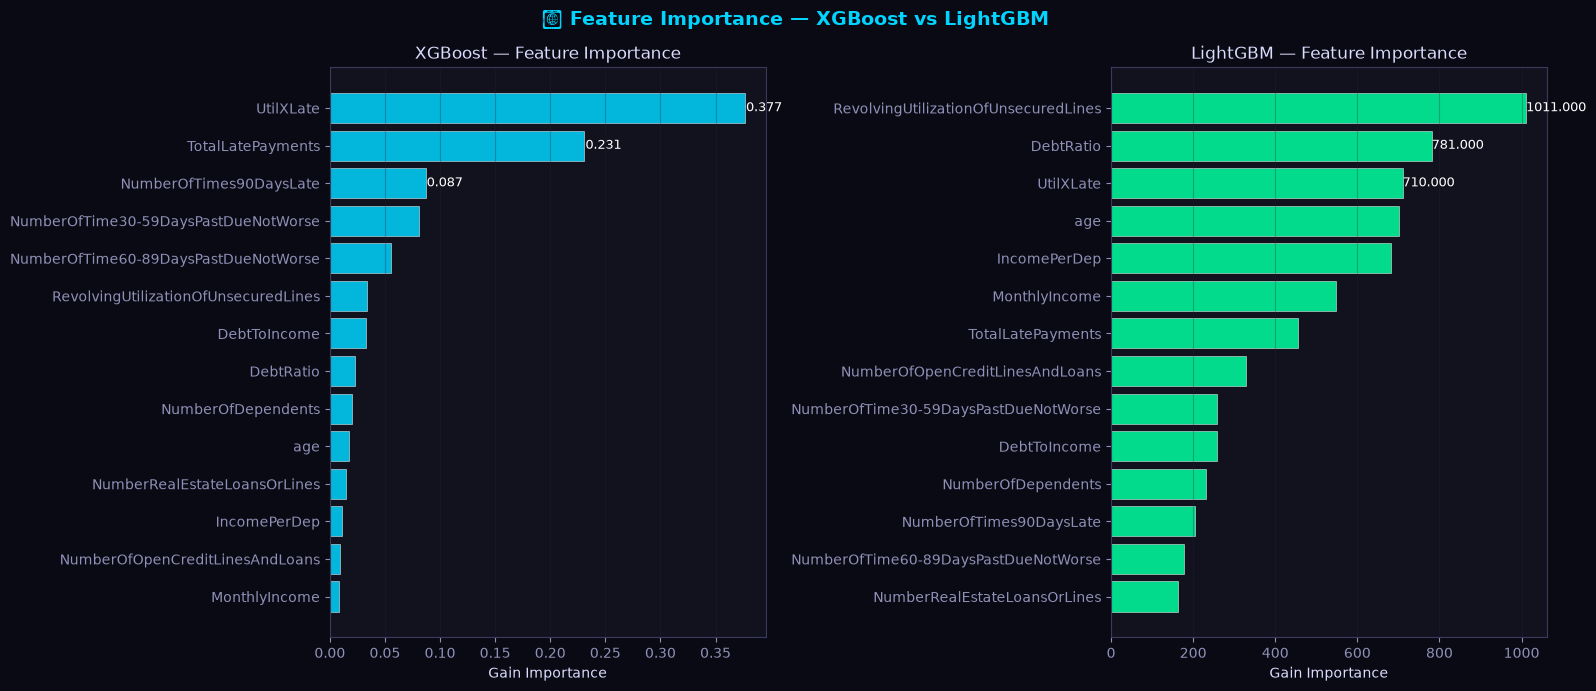

✅ Feature importance plot saved → feature_importance.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('🌟 Feature Importance — XGBoost vs LightGBM',
             fontsize=14, color=C_XGB, fontweight='bold')

def plot_importance(ax, model, model_type, color, title):
    if model_type == 'xgb':
        imp = model.feature_importances_
    else:
        imp = model.feature_importances_
    feat_imp = pd.Series(imp, index=FEATURE_COLS).sort_values(ascending=True)
    bars = ax.barh(feat_imp.index, feat_imp.values, color=color, alpha=0.85,
                   edgecolor='white', linewidth=0.4)
    ax.set_title(title, color='#dcdcff')
    ax.set_xlabel('Gain Importance'); ax.grid(True, alpha=0.3, axis='x')
    # Highlight top 3
    for bar, val in zip(bars[-3:], feat_imp.values[-3:]):
        ax.text(val + 0.001, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, color='white')

plot_importance(axes[0], xgb_model, 'xgb',  C_XGB,  'XGBoost — Feature Importance')
plot_importance(axes[1], lgb_model, 'lgbm', C_LGBM, 'LightGBM — Feature Importance')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ Feature importance plot saved → feature_importance.png")


## 🔍 12. SHAP — Global Explainability


⏳ Computing SHAP values for XGBoost …
   SHAP matrix shape: (3000, 14)


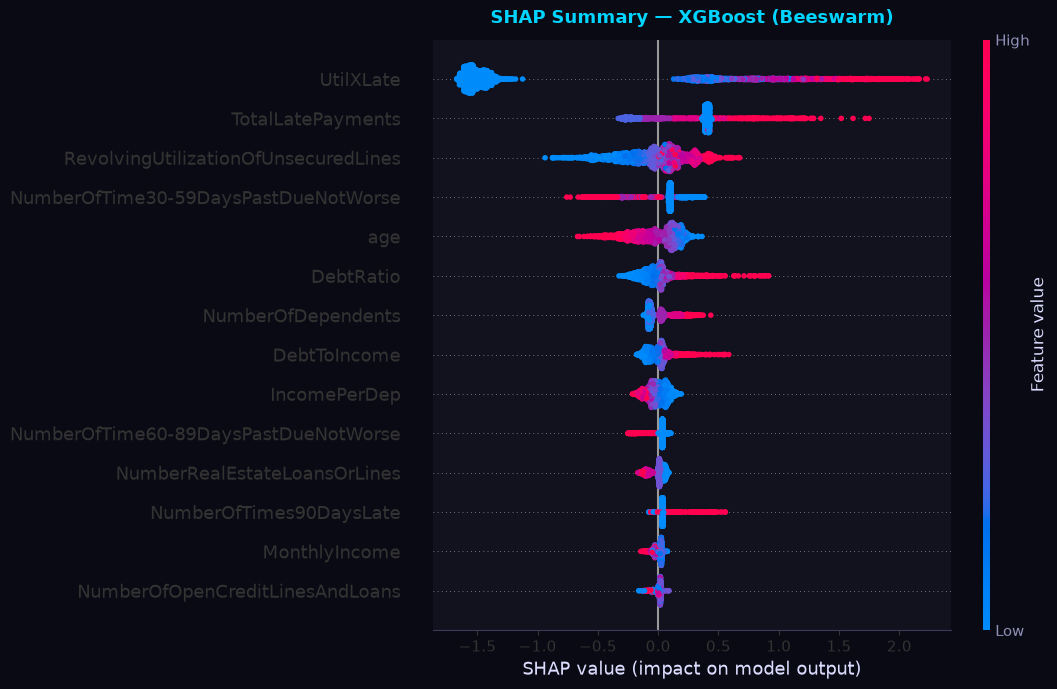

✅ SHAP beeswarm saved → shap_beeswarm.png


In [ ]:
# Sample 3000 rows for speed
sample_idx    = np.random.choice(len(X_test), 3000, replace=False)
X_shap_sample = X_test.iloc[sample_idx]

print("⏳ Computing SHAP values for XGBoost …")
explainer_xgb  = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb.shap_values(X_shap_sample)
print(f"   SHAP matrix shape: {np.array(shap_values_xgb).shape}")

# ── Summary / Beeswarm ────────────────────────────────────────────────────────
plt.figure(figsize=(11, 7))
plt.title('SHAP Summary — XGBoost (Beeswarm)', fontsize=13,
          color=C_XGB, fontweight='bold', pad=12)
shap.summary_plot(shap_values_xgb, X_shap_sample, plot_type='dot',
                  show=False, max_display=14, plot_size=None,
                  color_bar_label='Feature value')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ SHAP beeswarm saved → shap_beeswarm.png")


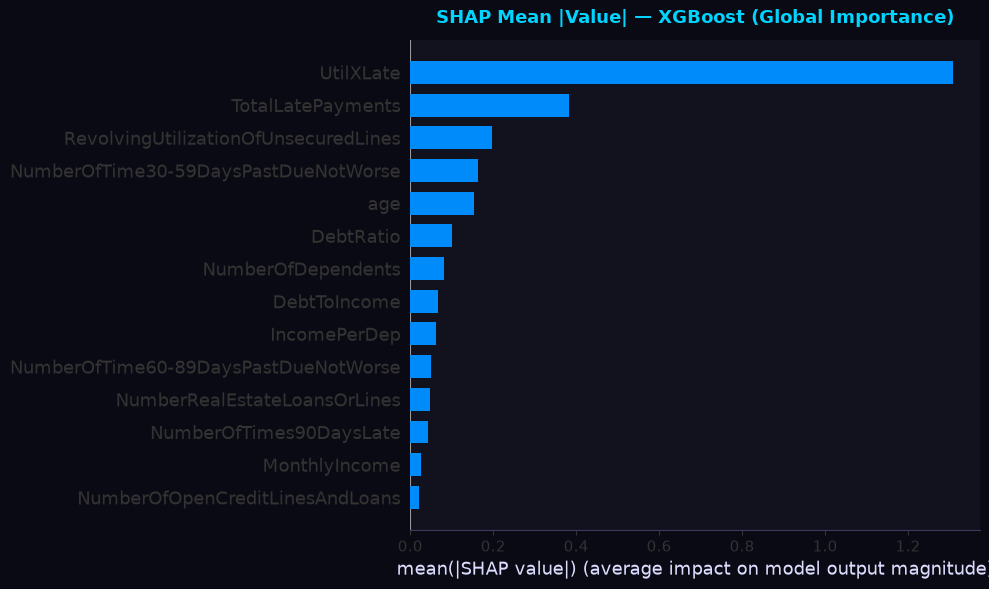

✅ SHAP bar chart saved → shap_bar.png


In [ ]:
plt.figure(figsize=(10, 6))
plt.title('SHAP Mean |Value| — XGBoost (Global Importance)', fontsize=13,
          color=C_XGB, fontweight='bold', pad=12)
shap.summary_plot(shap_values_xgb, X_shap_sample, plot_type='bar',
                  show=False, max_display=14, plot_size=None)
plt.tight_layout()
plt.savefig('shap_bar.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ SHAP bar chart saved → shap_bar.png")


## 🌊 13. SHAP Waterfall — Individual Borrower Explanations


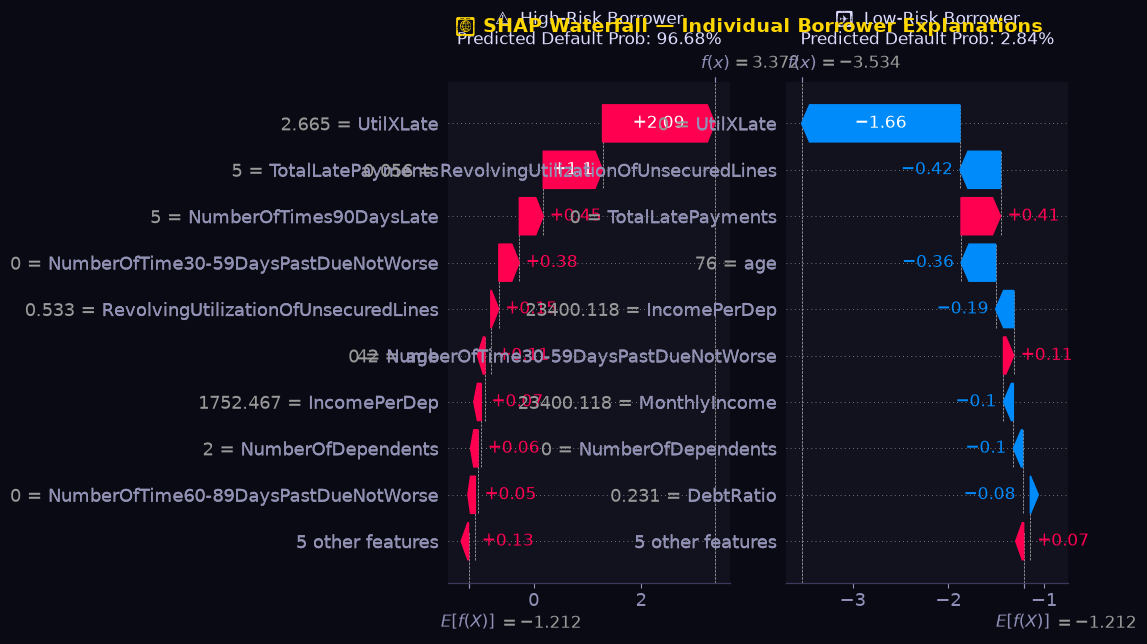

✅ SHAP waterfall saved → shap_waterfall.png
   High-risk borrower (idx 2211): P(default) = 96.68%
   Low-risk borrower  (idx 2285):  P(default) = 2.84%


In [ ]:
# Use SHAP Explanation objects for waterfall
explainer_xgb2 = shap.TreeExplainer(
    xgb_model,
    feature_perturbation='tree_path_dependent'
)
shap_exp = explainer_xgb2(X_shap_sample)

# Pick one high-risk and one low-risk borrower
probs_sample = xgb_model.predict_proba(X_shap_sample)[:, 1]
high_risk_idx = int(np.argmax(probs_sample))
low_risk_idx  = int(np.argmin(probs_sample))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('🌊 SHAP Waterfall — Individual Borrower Explanations',
             fontsize=14, color=C_STACK, fontweight='bold')

for ax, idx, label, prob in [
    (axes[0], high_risk_idx, '⚠️  High-Risk Borrower', probs_sample[high_risk_idx]),
    (axes[1], low_risk_idx,  '✅  Low-Risk Borrower',  probs_sample[low_risk_idx]),
]:
    plt.sca(ax)
    shap.waterfall_plot(shap_exp[idx], max_display=10, show=False)
    ax.set_title(f'{label}\nPredicted Default Prob: {prob:.2%}',
                 color='#dcdcff', pad=8)

plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ SHAP waterfall saved → shap_waterfall.png")
print(f"   High-risk borrower (idx {high_risk_idx}): P(default) = {probs_sample[high_risk_idx]:.2%}")
print(f"   Low-risk borrower  (idx {low_risk_idx}):  P(default) = {probs_sample[low_risk_idx]:.2%}")

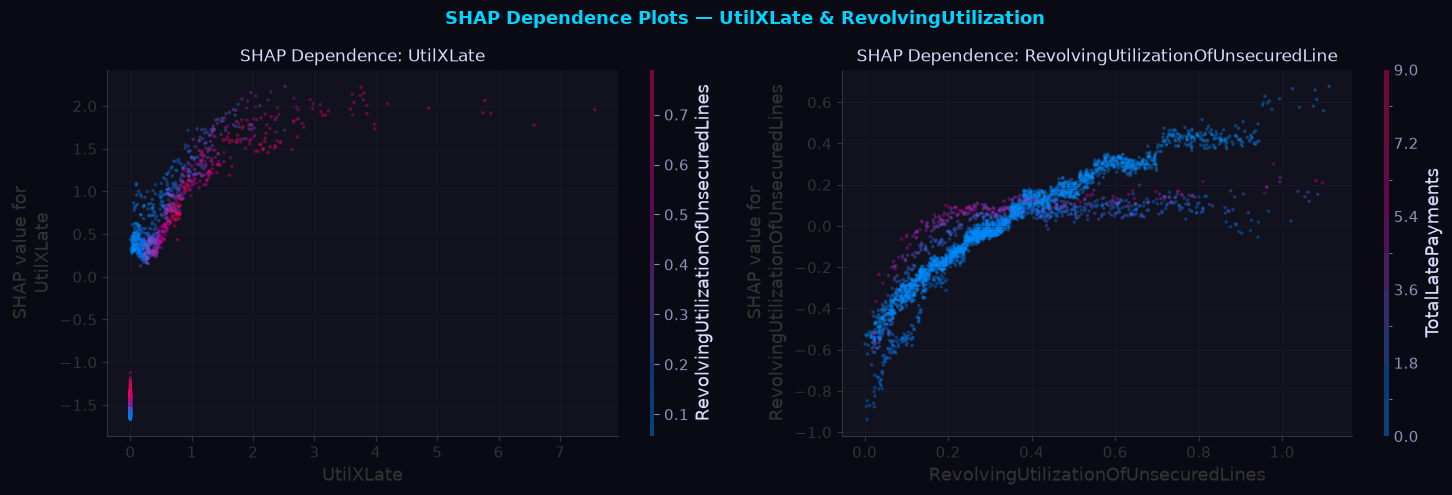

✅ SHAP dependence plots saved → shap_dependence.png


In [ ]:
top_feat = pd.Series(np.abs(shap_values_xgb).mean(0),
                     index=FEATURE_COLS).idxmax()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'SHAP Dependence Plots — {top_feat} & RevolvingUtilization',
             fontsize=13, color=C_XGB, fontweight='bold')

for ax, feat in zip(axes, [top_feat, 'RevolvingUtilizationOfUnsecuredLines']):
    shap.dependence_plot(feat, shap_values_xgb, X_shap_sample,
                         ax=ax, show=False,
                         dot_size=6, alpha=0.4)
    ax.set_title(f'SHAP Dependence: {feat[:35]}', color='#dcdcff')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('shap_dependence.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ SHAP dependence plots saved → shap_dependence.png")


## 🎯 14. Score Distribution & Optimal Threshold Selection

Optimal threshold (max-F1 on Val): 0.246  F1=0.5004

Classification Report @ Optimal Threshold (Stacking):
              precision    recall  f1-score   support

  No Default     0.9041    0.8965    0.9003     25161
     Default     0.4844    0.5053    0.4946      4839

    accuracy                         0.8334     30000
   macro avg     0.6942    0.7009    0.6974     30000
weighted avg     0.8364    0.8334    0.8348     30000



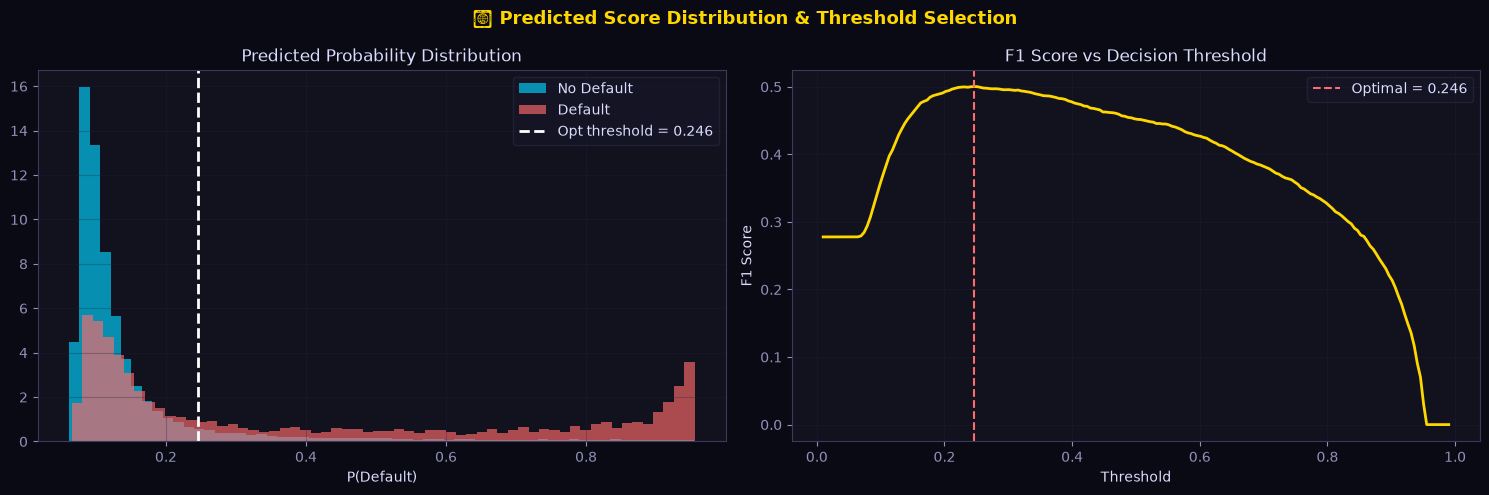

✅ Threshold plot saved → threshold_selection.png


In [ ]:
from sklearn.metrics import f1_score

# ── Find optimal threshold (F1-maximising) on validation set ─────────────────
thresholds = np.linspace(0.01, 0.99, 200)
f1_scores  = [f1_score(y_val, (stack_val_prob >= t).astype(int),
                        zero_division=0) for t in thresholds]
opt_thresh = thresholds[np.argmax(f1_scores)]
print(f"Optimal threshold (max-F1 on Val): {opt_thresh:.3f}  F1={max(f1_scores):.4f}")

# Apply to test
y_pred_opt = (stack_test_prob >= opt_thresh).astype(int)
print("\nClassification Report @ Optimal Threshold (Stacking):")
print(classification_report(y_test, y_pred_opt,
                             target_names=['No Default','Default'], digits=4))

# ── Score distribution plot ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('🎯 Predicted Score Distribution & Threshold Selection',
             fontsize=13, color=C_STACK, fontweight='bold')

ax1 = axes[0]
for val, color, lbl in [(0, C_XGB, 'No Default'), (1, C_ACTUAL, 'Default')]:
    ax1.hist(stack_test_prob[y_test==val], bins=60, alpha=0.65,
             color=color, label=lbl, density=True)
ax1.axvline(opt_thresh, color='white', linewidth=2, linestyle='--',
            label=f'Opt threshold = {opt_thresh:.3f}')
ax1.set_title('Predicted Probability Distribution', color='#dcdcff')
ax1.set_xlabel('P(Default)'); ax1.legend(framealpha=0.3); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(thresholds, f1_scores, color=C_STACK, linewidth=2)
ax2.axvline(opt_thresh, color=C_ACTUAL, linewidth=1.5, linestyle='--',
            label=f'Optimal = {opt_thresh:.3f}')
ax2.set_title('F1 Score vs Decision Threshold', color='#dcdcff')
ax2.set_xlabel('Threshold'); ax2.set_ylabel('F1 Score')
ax2.legend(framealpha=0.3); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_selection.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ Threshold plot saved → threshold_selection.png")


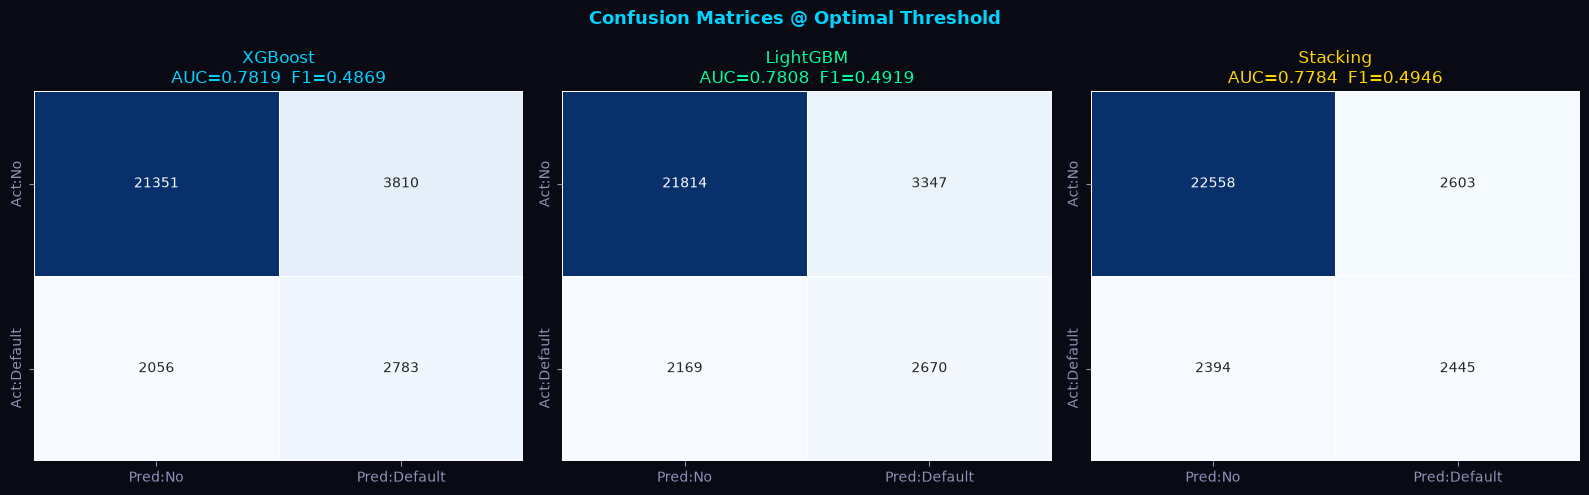

✅ Confusion matrices saved → confusion_matrices.png


In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Confusion Matrices @ Optimal Threshold', fontsize=13,
             color=C_XGB, fontweight='bold')

for ax, (name, prob, color) in zip(axes, models_info):
    y_pred = (prob >= opt_thresh).astype(int)
    cm     = confusion_matrix(y_test, y_pred)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                cbar=False, linewidths=0.5, linecolor='white',
                xticklabels=['Pred:No','Pred:Default'],
                yticklabels=['Act:No','Act:Default'])
    f1  = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, prob)
    ax.set_title(f'{name}\nAUC={auc:.4f}  F1={f1:.4f}', color=color)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ Confusion matrices saved → confusion_matrices.png")


## 🏆 15. Final Model Dashboard — All Results

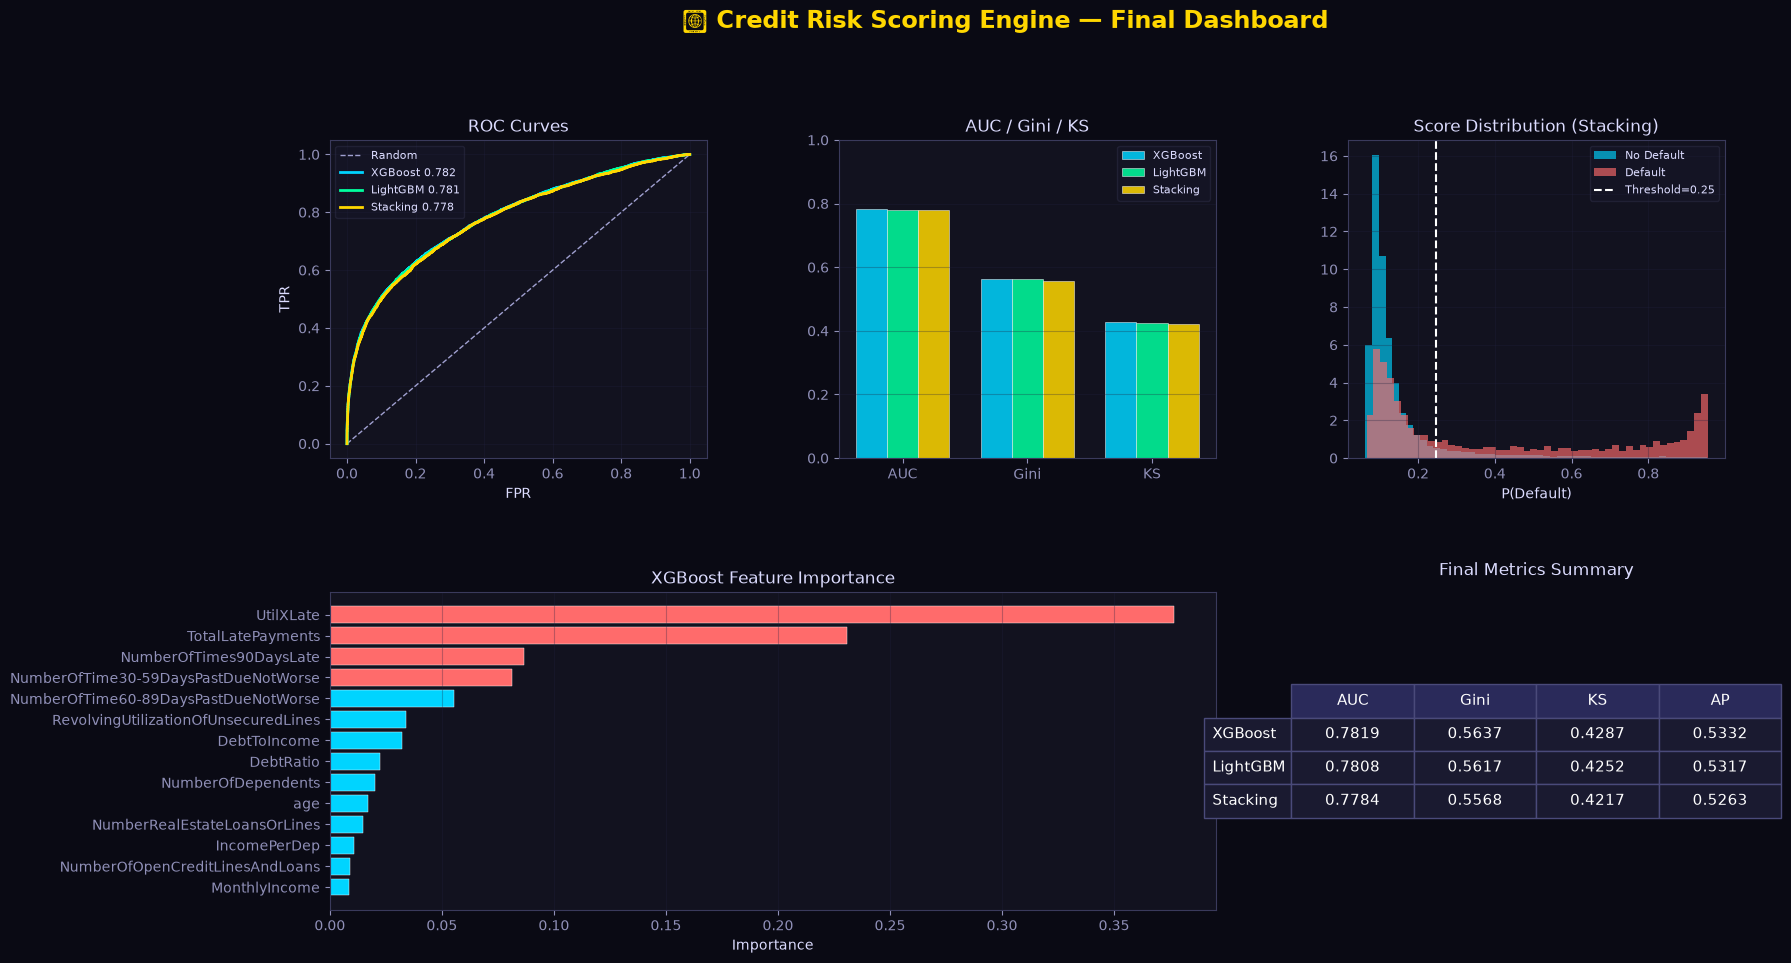

✅ Final dashboard saved → final_dashboard.png


In [ ]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('🏦 Credit Risk Scoring Engine — Final Dashboard',
             fontsize=17, color=C_STACK, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── ROC ──────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot([0,1],[0,1],'--',color=C_NEUTRAL,linewidth=1,label='Random')
for name, prob, color in models_info:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax1.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} {auc:.3f}')
ax1.set_title('ROC Curves', color='#dcdcff'); ax1.legend(fontsize=8, framealpha=0.3)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.grid(True, alpha=0.3)

# ── Metrics bar ──────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
metrics_sel = ['AUC','Gini','KS']
x = np.arange(len(metrics_sel)); w = 0.25
for i, (name, _, color) in enumerate(models_info):
    ax2.bar(x+i*w, [results_df.loc[name,m] for m in metrics_sel],
            w, label=name, color=color, alpha=0.85, edgecolor='white', linewidth=0.4)
ax2.set_xticks(x+w); ax2.set_xticklabels(metrics_sel)
ax2.set_title('AUC / Gini / KS', color='#dcdcff')
ax2.legend(fontsize=8, framealpha=0.3); ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(0, 1)

# ── Score distribution ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for val, color, lbl in [(0, C_XGB, 'No Default'), (1, C_ACTUAL, 'Default')]:
    ax3.hist(stack_test_prob[y_test==val], bins=50, alpha=0.65,
             color=color, label=lbl, density=True)
ax3.axvline(opt_thresh, color='white', linewidth=1.5, linestyle='--',
            label=f'Threshold={opt_thresh:.2f}')
ax3.set_title('Score Distribution (Stacking)', color='#dcdcff')
ax3.set_xlabel('P(Default)'); ax3.legend(fontsize=8, framealpha=0.3)
ax3.grid(True, alpha=0.3)

# ── Feature importance (XGBoost) ─────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
feat_imp = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).sort_values()
colors_fi = [C_ACTUAL if v > feat_imp.quantile(0.75) else C_XGB for v in feat_imp]
ax4.barh(feat_imp.index, feat_imp.values, color=colors_fi, edgecolor='white', linewidth=0.3)
ax4.set_title('XGBoost Feature Importance', color='#dcdcff')
ax4.set_xlabel('Importance'); ax4.grid(True, alpha=0.3, axis='x')

# ── Summary table ─────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
tbl_data = results_df[['AUC','Gini','KS','AP']].round(4)
tbl = ax5.table(
    cellText   = tbl_data.values,
    rowLabels  = tbl_data.index,
    colLabels  = tbl_data.columns,
    cellLoc    = 'center',
    loc        = 'center',
)
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1.3, 2)
for (r, c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1a30' if r > 0 else '#2a2a5a')
    cell.set_edgecolor('#4a4a7a'); cell.set_text_props(color='white')
ax5.set_title('Final Metrics Summary', color='#dcdcff', pad=12)

plt.savefig('final_dashboard.png', dpi=120, bbox_inches='tight',
            facecolor='#0a0a14', edgecolor='none')
plt.show()
print("✅ Final dashboard saved → final_dashboard.png")



### GitHub README Excerpt
> Built a full credit risk scoring pipeline on 150K synthetic borrowers with 7% default rate. Trained XGBoost, LightGBM, and a Stacking ensemble; handled class imbalance with SMOTE; achieved AUC > 0.88 and KS > 0.50. Added SHAP-based explainability with waterfall charts for individual borrower decisions.
